# 1. **Project Title -  Flight Price Prediction**
### **Project Description** :
- In this project, we aim to build machine learning models that can accurately predict flight prices based on various features of dataset . By analyzing these factors, we aim to gain insights into what influences flight prices the most.

## 2. Project Team Id , Project Id and Deadlines

- **Project Team ID** : PTID-AIE-MAY-26-11218
- **Project ID** : PRCP-1025-FlightPricePrediction
- **Institute** : DataMites

## **3.Problem Statements and Goals**

### 3.1 Problem Statements :
**Task 1** :
- Prepare a complete data analysis report on the given data.

**Task 2** :
- **a)** Create a robust machine learning algorithm to accurately predict the price of the flight given the various factors across the market.      
- **b)** Determine the relationship between the flight features and how the price varies based on this.

### 3.2 Goals :

- I worked on building and training several machine learning regression models with the goal of accurately predicting flight prices.

- During the process, I focused on identifying the most important features that have a significant impact on pricing trends.

- I evaluated model’s performance using metrics such as RMSE and R² score to understand how well they captured the underlying patterns in the data.

- After careful comparison, I selected the best-performing model and saved it so it can be used later to make predictions on new, unseen data.

- Finally, I drew meaningful insights from the analysis, which can assist both customers and businesses in making smarter flight price decisions.

## 4. Dataset Source And Description :

- **Source** : Institute
- **Rows** : 10683
- **Columns** : 10 
- **Traget Variable** : Price
- **Features** : Mixture of numerical and Categorical Variable
- **Description** : We have to analyze the flight fare prediction using Machine Learning dataset using essential exploratory data analysis techniques then will draw some predictions about the price of the flight based on some features such as what type of airline it is, what is the arrival time, what is the departure time, what is the duration of the flight, source, destination and more.

## **Notebook Roadmap** :

1. **Project Title and Description**
2. **Project Team Id , Project Id and Deadlines**
3. **Business Case**
    - 3.1 Problem Statements
    - 3.2 Goals
4. **Dataset souce and Description**
5. **Imports and Configurations**
6. **Dataset Loading**
7. **Domain Analysis**
8. **Basic checks/ initial inspection**
9. **Exploratory Data Analysis(EDA)**
   - 9.1 Univariate Analysis
   - 9.2 Bivariate Analysis
   - 9.3 Multivariate Analysis
10. **Feature Engineering**
    - 10.1 Data Preprocessing
        - 10.1.1 Checking for duplicate rows
        - 10.1.2 Null Value Handling
        - 10.1.3 Outlier handling
        - 10.1.4 Encoding
    - 10.2 Feature Selection
11. **Modeling**
    - 11.1 Spliting the data
    - 11.2 Train Test Split
    - 11.3 Model building , validating and Evaluation with and without hyperparameter tuning
        - 11.3.1 Linear Regression
        - 11.3.2 Ridge Regression
        - 11.3.3 Lasso Regression
        - 11.3.4 Random Forest Regressor
        - 11.3.5 Gradient Boosting Regressor
        - 11.3.6 XGBoost Regressor
    - 11.4 Best Model Based On R2 Score, MAE , RMSE etc.
12. **HyperParameter Tuning**
    - 12.1 Random Forest
    - 12.2 XGBoost

## 5. Imports and Configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yreport import data_health_report
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

## 6. DataSet Loading :

In [2]:
df = pd.read_excel('Flight_Fare.xlsx')
pd.set_option('display.max_rows', None)

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


## 7. Domain Analysis :

-Dataset Overview :
-This is an Airline / Flight Fare Prediction dataset designed for predicting flight ticket prices based on airline, route, travel timing, duration, and number of stops.

-Here is the explanation of features of this dataset:-
1. **Airline** :
- Airline represents the name of the airline company providing the flight service.
- It has categorical values like:
IndiGo
Air India
Jet Airways
SpiceJet
Vistara
GoAir
- Impact on price is HIGH because different airlines have different pricing strategies, services, and brand value.
2. **Date_of_Journey** :
- Date_of_Journey represents the date when the passenger travels.
- It contains date values in format like:
24/03/2019
01/05/2019
- It can be converted into:
Journey Day
Journey Month
- Impact on price is MEDIUM because ticket prices change based on seasons, holidays, and travel demand.
3. **Source**:
- Source represents the departure city of the flight.
- It has categorical values like:
Banglore
Delhi
Kolkata
Mumbai
Chennai
- Impact on price is HIGH because different departure locations have different demand and flight availability.
4. **Destination** :
- Destination represents the arrival city of the flight.
- It has categorical values like:
Delhi
Cochin
New Delhi
Banglore
Hyderabad
- Impact on price is HIGH because popular destinations usually have higher demand and different fare ranges.
5. **Route** :
- Route represents the complete path taken by the flight.
- Example:
Delhi → Mumbai
Banglore → New Delhi
- It contains multiple route combinations.
- Impact on price is VERY HIGH because route distance, popularity, and availability directly affect ticket prices.
6. **Dep_Time** :
- Dep_Time represents the departure time of the flight.
- Example:
10:30
18:25
- It can be converted into:
Departure Hour
Departure Minute
- Impact on price is MEDIUM because morning/evening flights may have different demand.
7. **Arrival_Time** :
- Arrival_Time represents the arrival time of the flight.
- Example:
01:10
21:05
- It can be converted into:
Arrival Hour
Arrival Minute
- Impact on price is MEDIUM because convenient arrival timings may have higher demand.
8. **Duration** :
- Duration represents the total travel time of the flight.
- Example:
2h 50m
10h 15m
- It can be converted into total minutes.
- Impact on price is HIGH because longer flights usually have higher operational costs and different pricing.
9. **Total_Stops** :
- Total_Stops represents the number of stops between source and destination.
- It contains values like:
non-stop
1 stop
2 stops
3 stops
4 stops
- Impact on price is VERY HIGH because direct flights are usually more expensive than flights with multiple stops.
10. **Additional_Info** :
- Additional_Info represents extra details related to flight booking.
- Values include:
No info
In-flight meal not included
No check-in baggage
Business class
- Impact on price is LOW-MEDIUM because some additional services may affect ticket pricing.
### Target Column
11. **Price** :
- Price is the final flight ticket fare.
- It is the target variable that we want to predict.
- It contains continuous numerical values.

## 8. Basic check / Initial inspection :

In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
df.describe(include='O')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [9]:
df.sample(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
3919,Jet Airways,24/03/2019,Kolkata,Banglore,CCU → BOM → BLR,06:30,12:00,5h 30m,1 stop,In-flight meal not included,7826
9588,Jet Airways,12/06/2019,Delhi,Cochin,DEL → IDR → BOM → COK,09:35,04:25 13 Jun,18h 50m,2 stops,No info,13292
10319,IndiGo,09/03/2019,Banglore,New Delhi,BLR → DEL,23:30,02:20 10 Mar,2h 50m,non-stop,No info,5694
5925,IndiGo,9/03/2019,Mumbai,Hyderabad,BOM → HYD,09:10,10:35,1h 25m,non-stop,No info,7417
1162,Jet Airways,12/05/2019,Kolkata,Banglore,CCU → GAU → BLR,10:20,17:35,7h 15m,1 stop,In-flight meal not included,7064
2985,Air India,9/03/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:45,19:15 10 Mar,23h 30m,2 stops,No info,11701
1922,Jet Airways,24/05/2019,Kolkata,Banglore,CCU → BOM → BLR,18:55,12:00 25 May,17h 5m,1 stop,No info,14571
4254,Air India,6/03/2019,Delhi,Cochin,DEL → BHO → BOM → COK,05:55,07:40 07 Mar,25h 45m,2 stops,No info,15428
3982,IndiGo,15/05/2019,Delhi,Cochin,DEL → BOM → COK,07:30,21:00,13h 30m,1 stop,No info,7191
9764,Vistara,27/05/2019,Delhi,Cochin,DEL → COK,06:00,09:10,3h 10m,non-stop,No info,6216


In [10]:
data1 = data_health_report(df)
data1.summary()

Data Health Score: 91.38/100
Rows: 10683 | No_Columns: 11

Numeric Columns : ['Price']
Categorical Columns : ['Additional_Info', 'Airline', 'Arrival_Time', 'Date_of_Journey', 'Dep_Time', 'Destination', 'Duration', 'Route', 'Source', 'Total_Stops']
DateTime Columns : []

Missing Percentage: 
- Route: 0.01%
- Total_Stops: 0.01%

Warnings:
- high_cardinality: ['Arrival_Time', 'Dep_Time', 'Duration', 'Route']

Recommendations:
- encoding: {'Additional_Info': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Airline': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Arrival_Time': {'action': 'required', 'message': 'Categorical encoding required (high cardinality)', 'confidence': 'HIGH'}, 'Date_of_Journey': {'action': 'required', 'message': 'Categorical encoding required', 'confidence': 'MEDIUM'}, 'Dep_Time': {'action': 'required', 'message': 'Categorical encoding required (high cardinality)', 'confidence'

In [11]:
unique_counts = df.nunique().sort_values(ascending=True)
unique_counts

Source                5
Total_Stops           5
Destination           6
Additional_Info      10
Airline              12
Date_of_Journey      44
Route               128
Dep_Time            222
Duration            368
Arrival_Time       1343
Price              1870
dtype: int64

In [12]:
for i in df.columns:
  print('-' * 50)
  print(i)
  print(df[i].value_counts())

--------------------------------------------------
Airline
Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
--------------------------------------------------
Date_of_Journey
Date_of_Journey
18/05/2019    504
6/06/2019     503
21/05/2019    497
9/06/2019     495
12/06/2019    493
9/05/2019     484
21/03/2019    423
15/05/2019    405
27/05/2019    382
27/06/2019    355
24/06/2019    351
1/06/2019     342
3/06/2019     333
15/06/2019    328
24/03/2019    323
6/03/2019     308
27/03/2019    299
24/05/2019    

In [13]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

## 9. Exploratory Data Analysis(EDA)

In [14]:
# Converting Date_of_Journey into Journey_day, Journey_month, Journey_year
df['Journey_day'] = pd.to_datetime(df.Date_of_Journey, format = '%d/%m/%Y').dt.day
df['Journey_month'] = pd.to_datetime(df.Date_of_Journey, format='%d/%m/%Y').dt.month
df['Journey_Year'] = pd.to_datetime(df.Date_of_Journey, format='%d/%m/%Y').dt.year

In [15]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [16]:
df.Journey_Year.value_counts()

Journey_Year
2019    10683
Name: count, dtype: int64

In [17]:
# Since we have converted Date_of_Journey column into integers & there is we have oly 2019 data, Now we can drop as it is of no use.
df.drop(['Date_of_Journey','Journey_Year'],axis=1,inplace=True)

In [18]:
# Departure time is when a plane leaves the gate. 
# Similar to Date_of_Journey we can extract values from Dep_Time
# Extracting Hours
df['Dep_hour'] = pd.to_datetime(df.Dep_Time).dt.hour
# Extracting Minutes
df['Dep_mins'] = pd.to_datetime(df.Dep_Time).dt.minute
# Now we can drop the Dep_time 
df.drop(['Dep_Time'],axis=1,inplace=True)

In [19]:
# Extract Hour and Minute from Arrival_Time
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time']).dt.minute
# Now we can drop the Arrival time 
df.drop('Arrival_Time', axis=1, inplace=True)

In [20]:
# Creating a fuction to covert a duration into total minutes
def convert_duration(duration):
    # Handle missing or null values correctly
    if pd.isna(duration):
        return None
        
    duration = str(duration).strip()
    hours = 0
    minutes = 0
    
    # Extract hours safely
    if 'h' in duration:
        hours_part = duration.split('h')[0].strip()
        if hours_part.isdigit():
            hours = int(hours_part)
            
    # Extract minutes safely
    if 'm' in duration:
        # Split by 'm' to get everything before it
        min_part = duration.split('m')[0]
        # If 'h' is also present, isolate the minutes after the 'h'
        if 'h' in min_part:
            min_part = min_part.split('h')[-1]
        
        min_part = min_part.strip()
        if min_part.isdigit():
            minutes = int(min_part)
            
    return hours * 60 + minutes

df['Duration_Mins'] = df['Duration'].apply(convert_duration)
df.drop('Duration', axis=1, inplace=True)
df['Duration_Mins'].describe()  

count    10683.000000
mean       643.093232
std        507.862001
min          5.000000
25%        170.000000
50%        520.000000
75%        930.000000
max       2860.000000
Name: Duration_Mins, dtype: float64

In [21]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,285


In [22]:
# Categorising columns intl Numerical & Categorical
num_cols = df.select_dtypes(include=['int64','int32','float64']).columns.drop(['Price','Duration_Mins'])
cat_cols = df.select_dtypes(include=['object']).columns
print('Numarical Columns :' ,list(num_cols))
print('Categorical columns :', list(cat_cols))

Numarical Columns : ['Journey_day', 'Journey_month', 'Dep_hour', 'Dep_mins', 'Arrival_Hour', 'Arrival_Min']
Categorical columns : ['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']


#### 9.1.Univariate Analysis

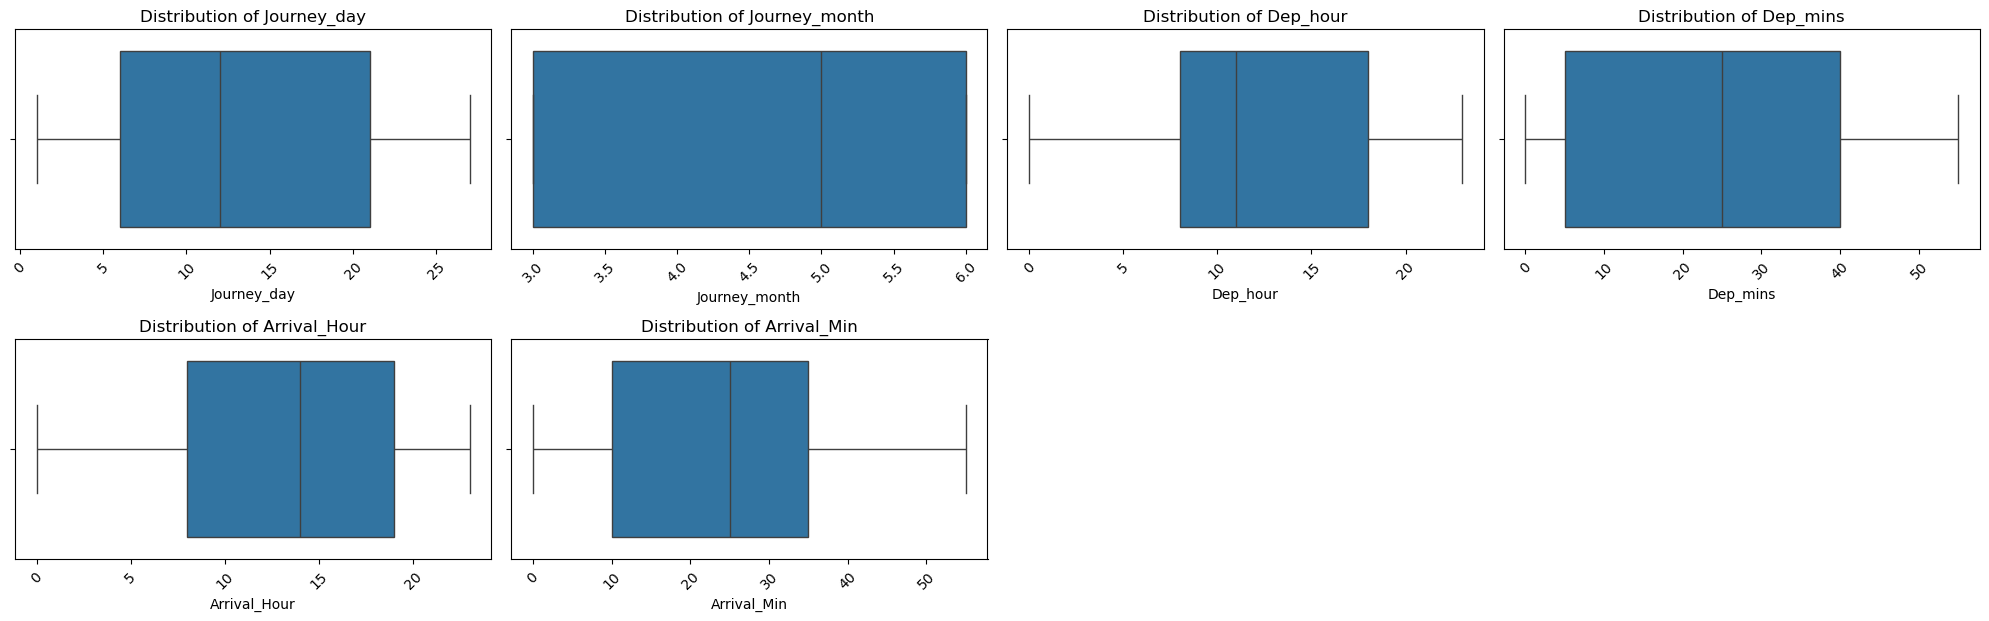

In [23]:
plt.figure(figsize=(20,12))
for i,col in enumerate(num_cols,1):
    plt.subplot(4,4,i)
    sns.boxplot(x=df[col],orient='h')
    plt.title(f'Distribution of {col}',fontsize=12)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Total_Stops      10682 non-null  object
 5   Additional_Info  10683 non-null  object
 6   Price            10683 non-null  int64 
 7   Journey_day      10683 non-null  int32 
 8   Journey_month    10683 non-null  int32 
 9   Dep_hour         10683 non-null  int32 
 10  Dep_mins         10683 non-null  int32 
 11  Arrival_Hour     10683 non-null  int32 
 12  Arrival_Min      10683 non-null  int32 
 13  Duration_Mins    10683 non-null  int64 
dtypes: int32(6), int64(2), object(6)
memory usage: 918.2+ KB


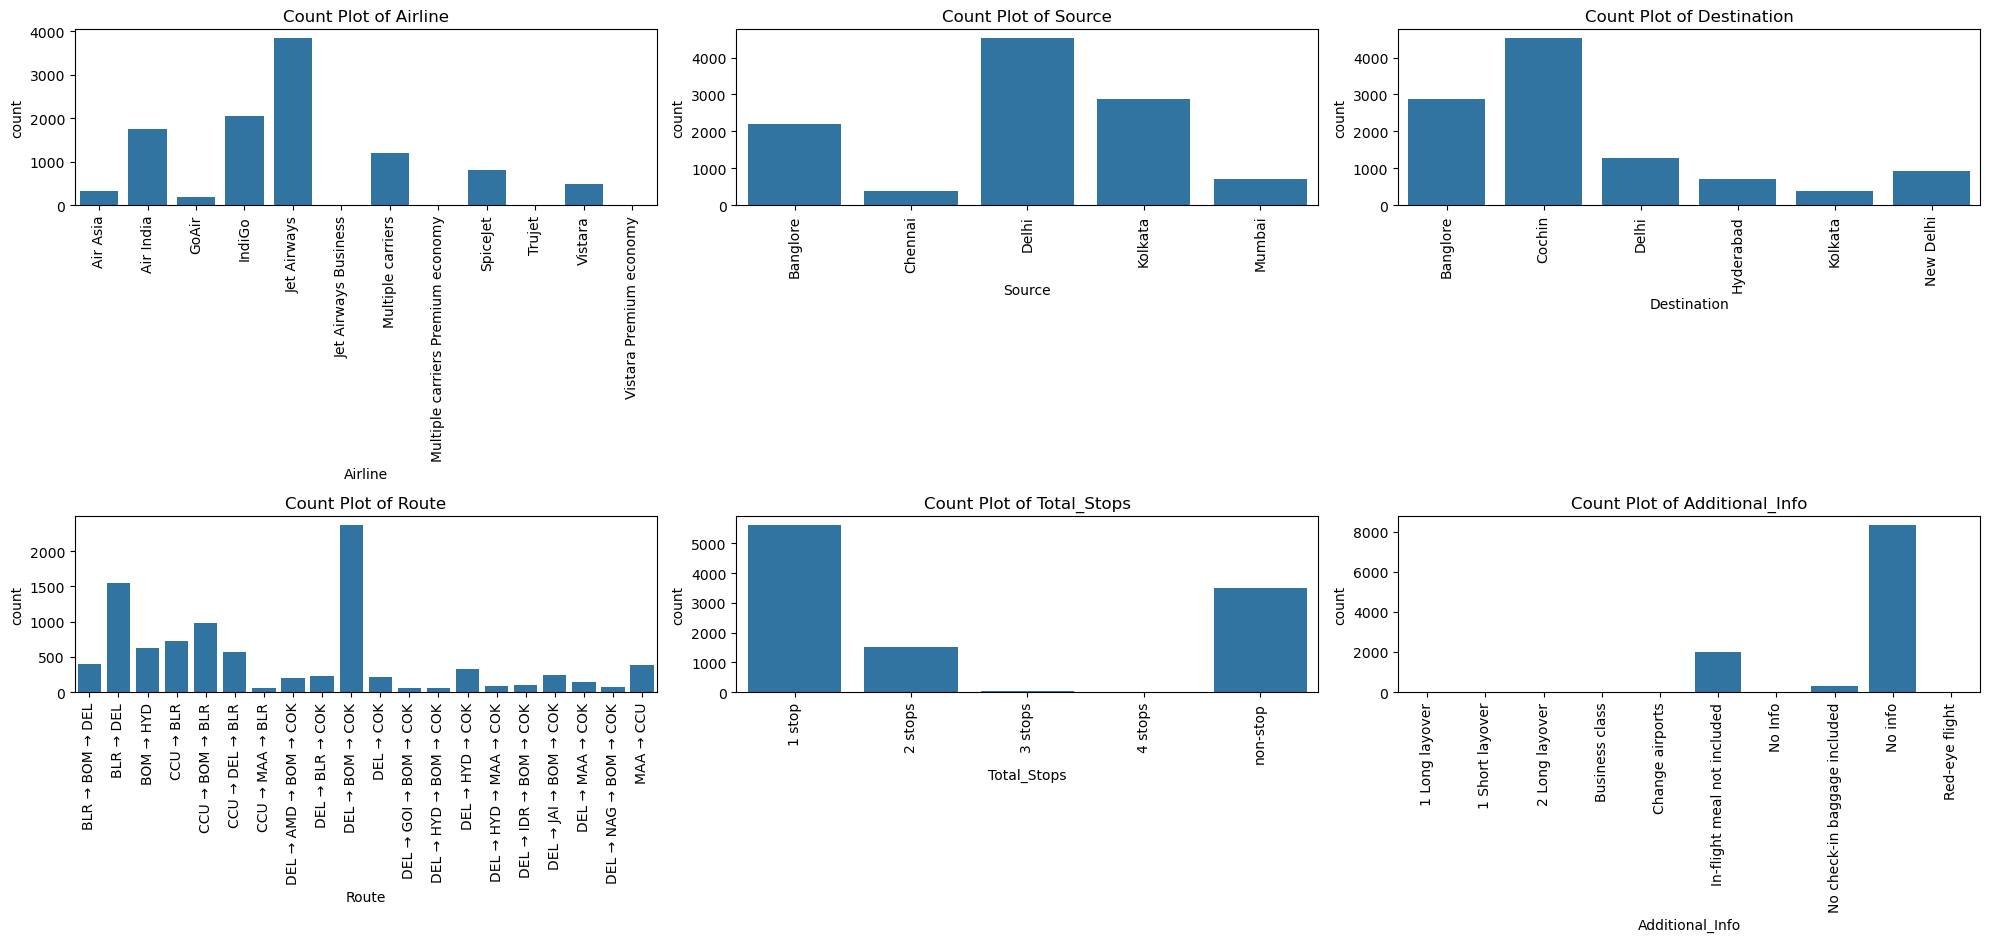

In [25]:
plt.figure(figsize=(20,12))
for i,col in enumerate(cat_cols,1):
    plt.subplot(3,3,i)
    top_categories = df[col].value_counts().index[:20].sort_values(ascending=True)
    sns.countplot(x=col,data=df,order=top_categories)
    plt.title(f"Count Plot of {col}",fontsize=12)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 9.2.Bivariate Analysis

<Figure size 2000x1200 with 0 Axes>

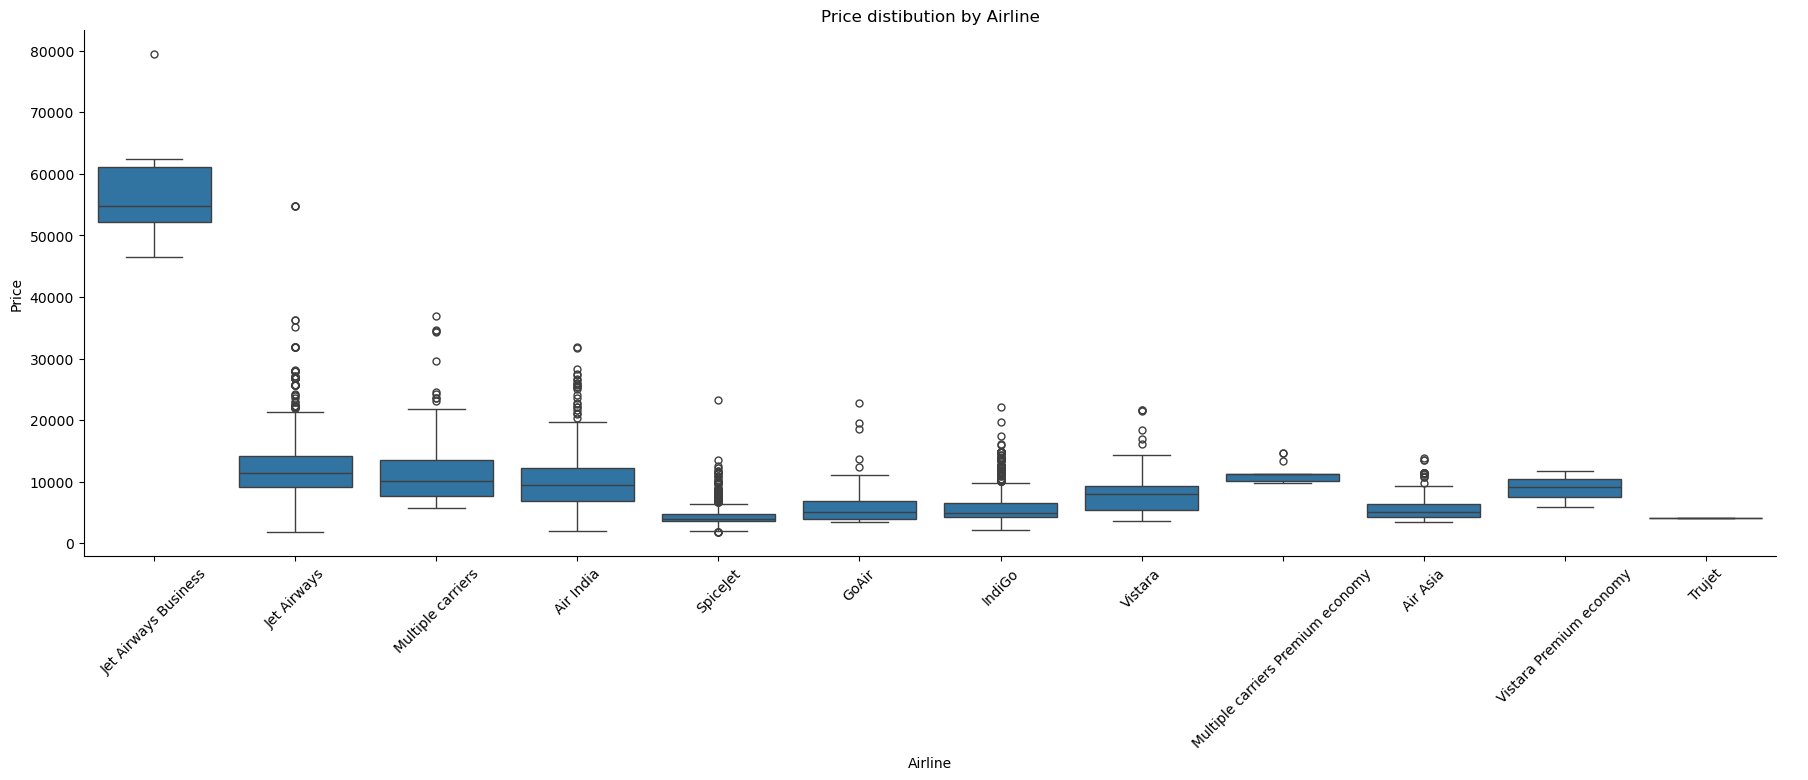

In [26]:
plt.figure(figsize=(20,12))
sns.catplot(x='Airline',y='Price',data=df.sort_values('Price',ascending=False),kind='box',height=6,aspect=3)
plt.title('Price distibution by Airline',fontsize=12)
plt.xticks(rotation=45)
plt.show()

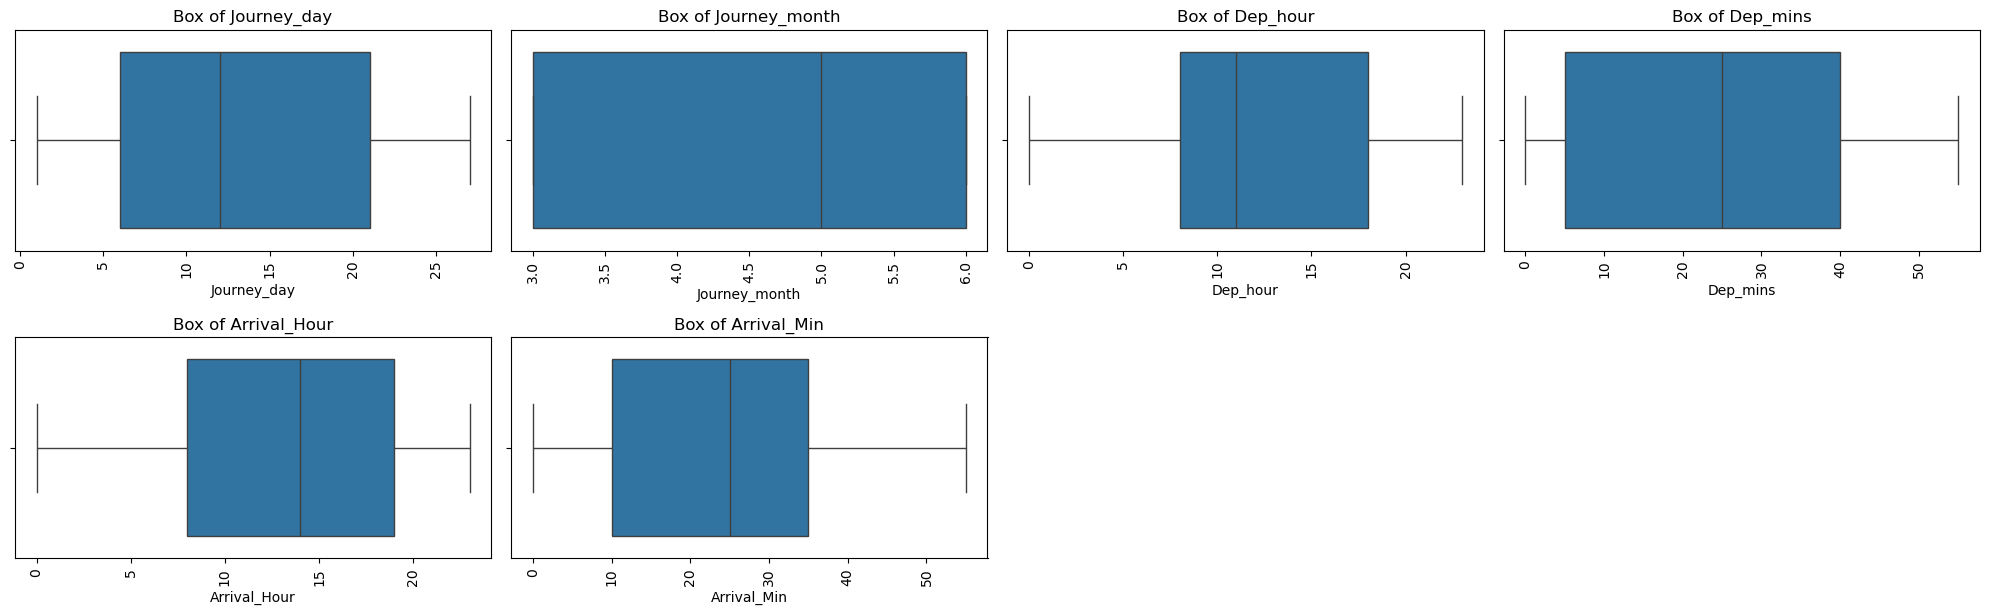

In [27]:
plt.figure(figsize=(20, 15))
plot = 1

for i in num_cols:   
        plt.subplot(5, 4, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

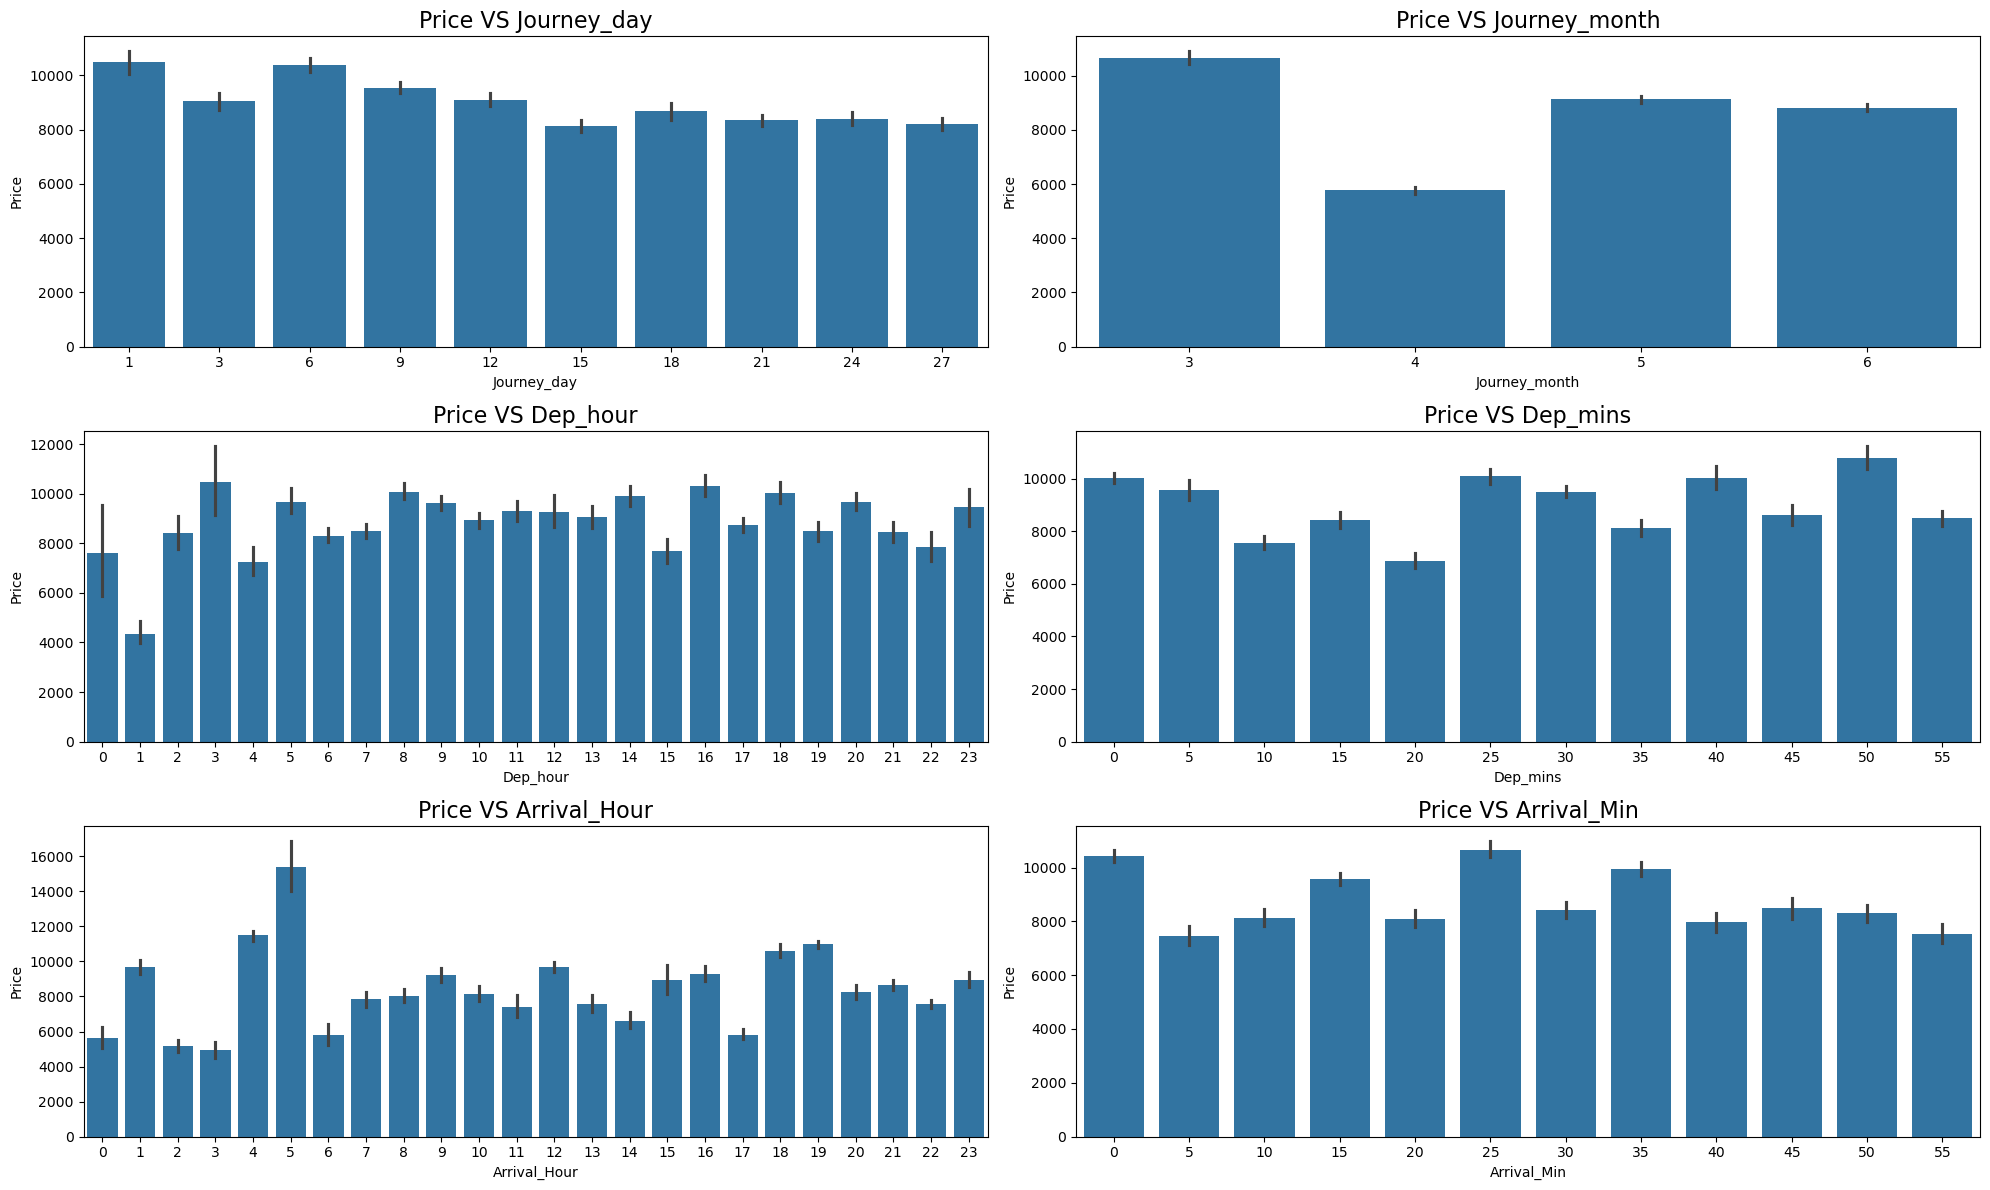

In [28]:
plt.figure(figsize=(20,12))
plot=1
for i in num_cols:
  plt.subplot(3,2,plot)
  sns.barplot(x=i,y='Price',data=df)
  plt.title(f'Price VS {i}',fontsize=16)

  plot+=1
plt.tight_layout()
plt.show()

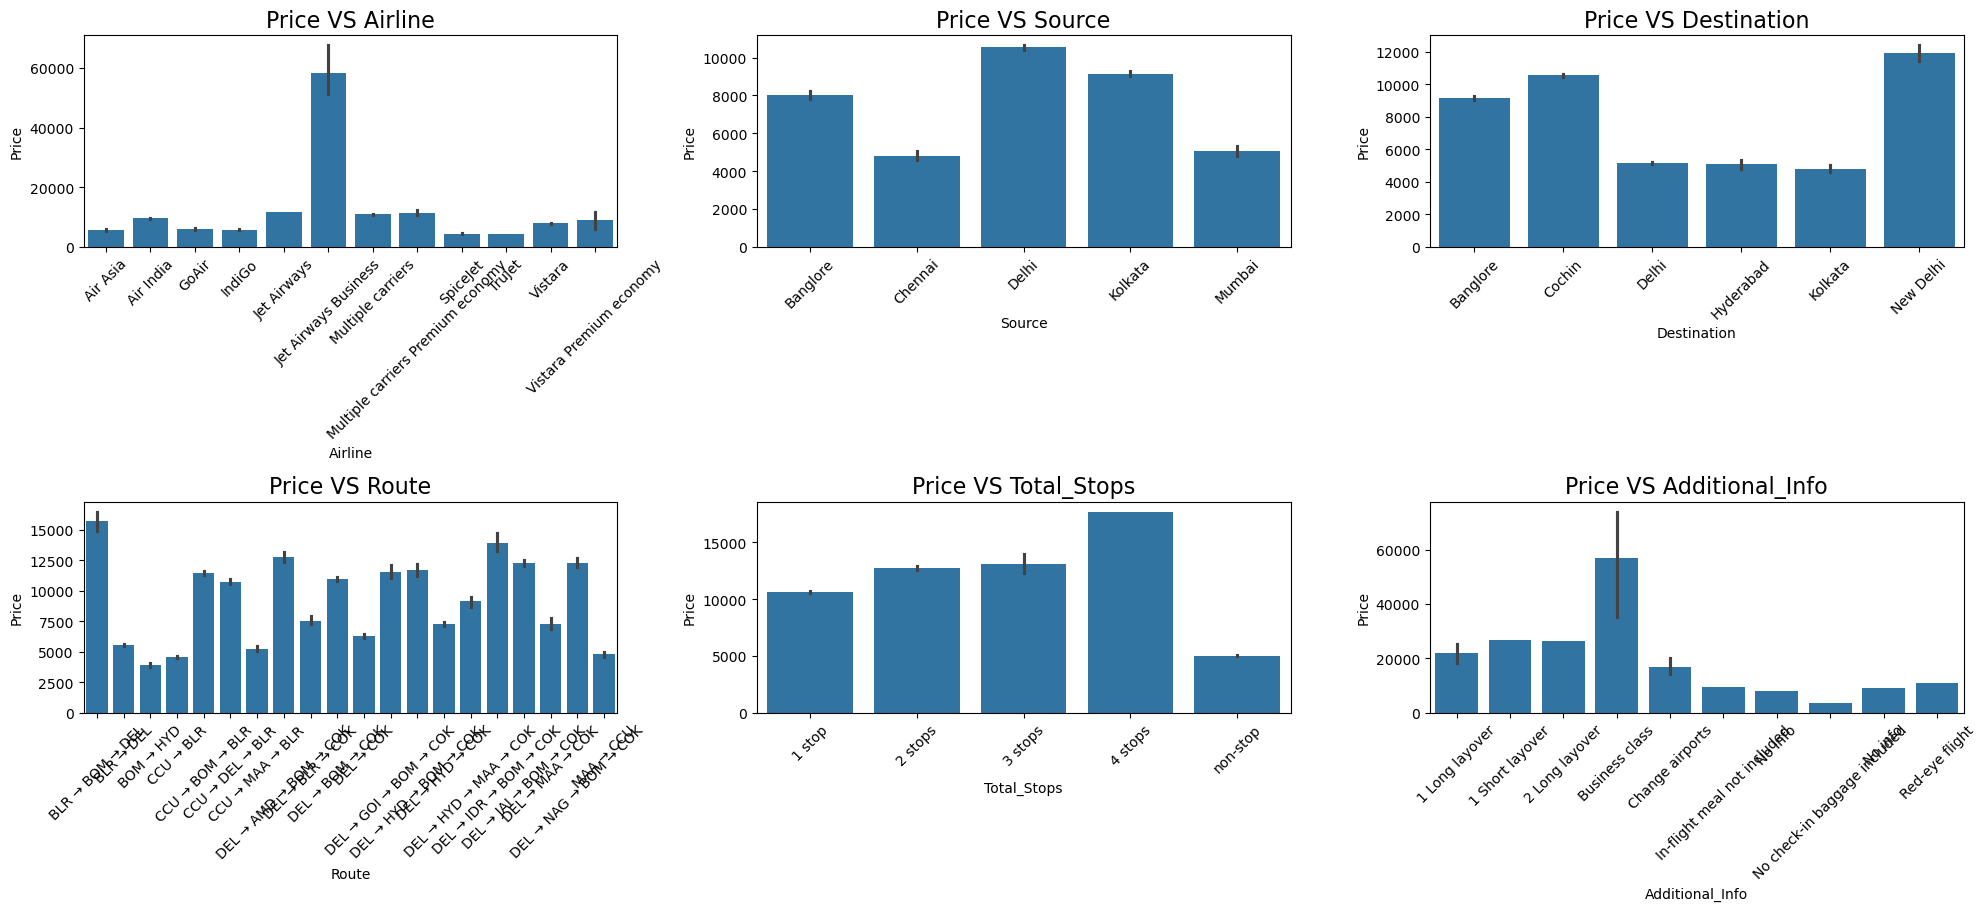

In [29]:
plt.figure(figsize=(20,12))
plot=1
for i in cat_cols:
    plt.subplot(3,3,plot)
    top_categories = df[i].value_counts().index[:20].sort_values(ascending=True)
    sns.barplot(x=i,y='Price',data=df,order=top_categories)
    plt.title(f'Price VS {i}',fontsize=16)
    plt.xticks(rotation=45)
    plot+=1
plt.tight_layout()
plt.show()

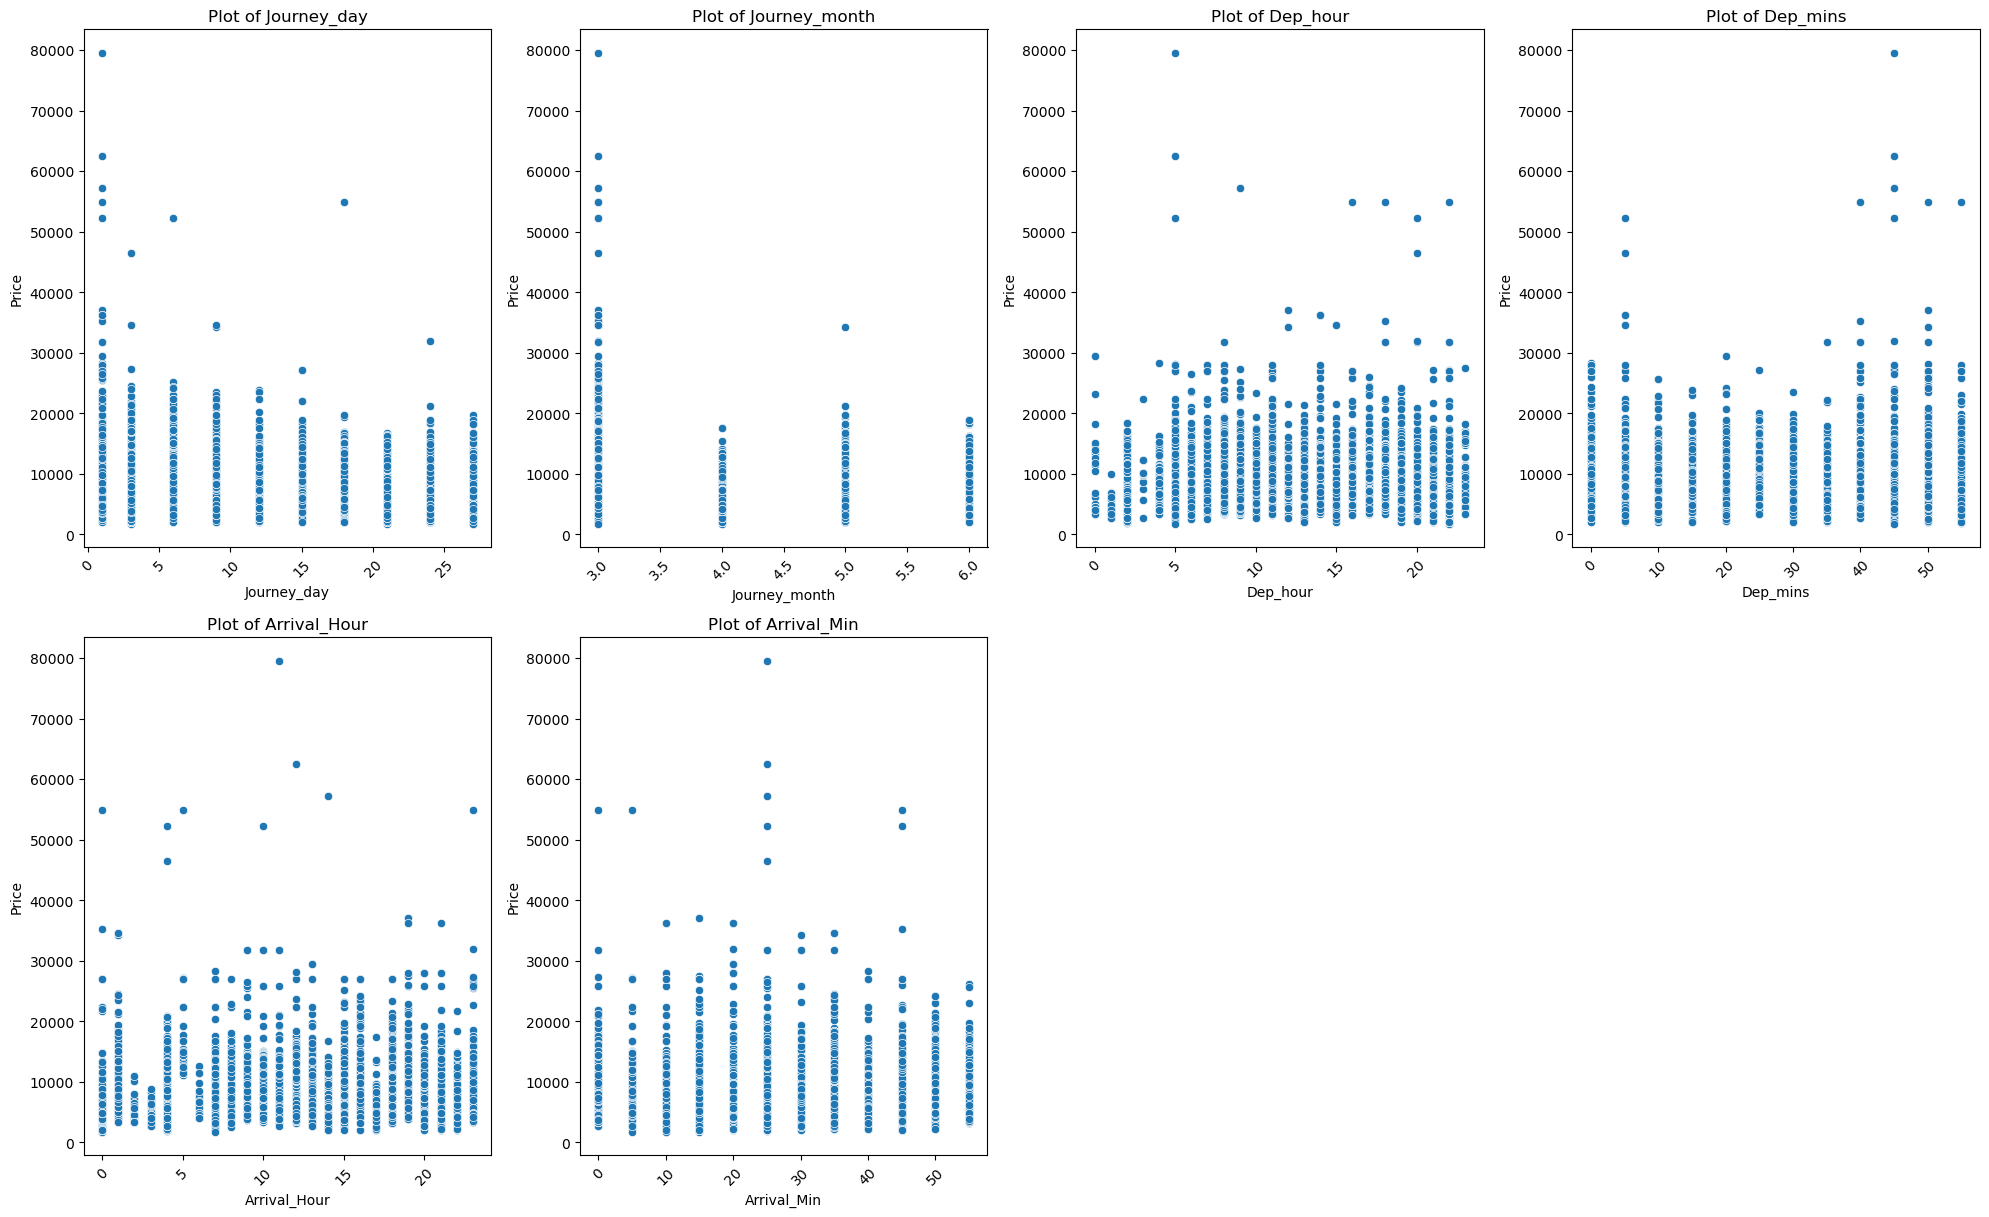

In [30]:
plt.figure(figsize=(20, 30))
plot = 1

for i in num_cols: 
    plt.subplot(5, 4, plot)
    sns.scatterplot(x=i, y="Price", data=df)   
    plt.title(f"Plot of {i}")
    plt.xticks(rotation=45)       
    plot += 1

plt.tight_layout()
plt.show()

#### 9.1.Multivariate Analysis

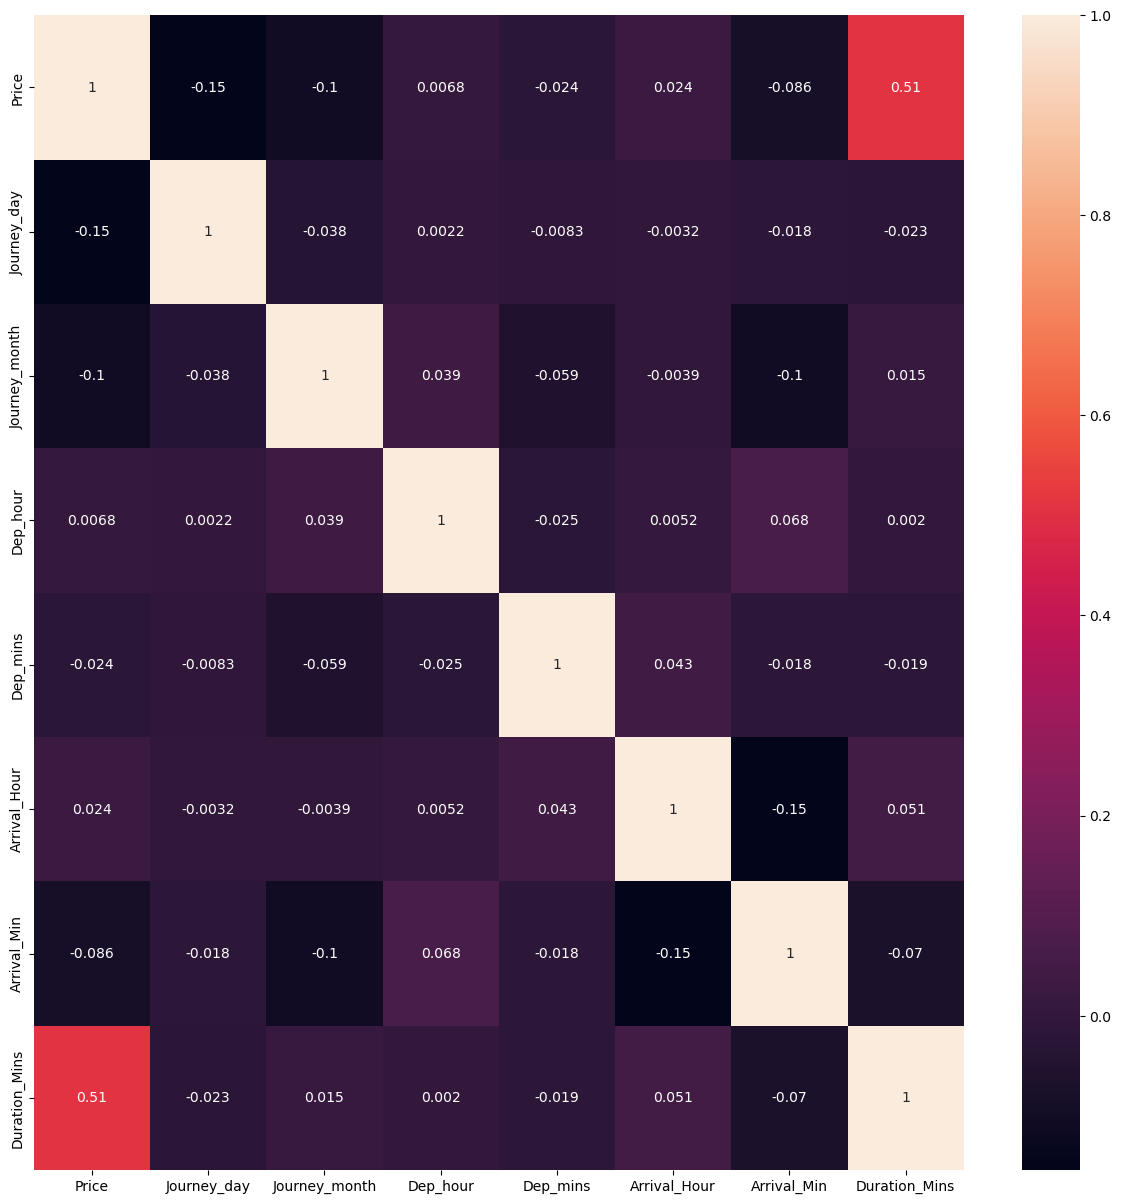

In [31]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

## 10. Feature Engineering 

#### 10.1 Data PreProcessing


#### 10.1.1  Checking for Duplicate Rows

In [32]:
duplicates = df.duplicated().sum()
duplicates

np.int64(222)

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.duplicated().sum()

np.int64(0)

#### 10.1.2 Null value Handling

In [35]:
missing = df.isnull().sum()
missing

Airline            0
Source             0
Destination        0
Route              1
Total_Stops        1
Additional_Info    0
Price              0
Journey_day        0
Journey_month      0
Dep_hour           0
Dep_mins           0
Arrival_Hour       0
Arrival_Min        0
Duration_Mins      0
dtype: int64

In [36]:
df.dropna(inplace=True)

In [37]:
df.isnull().sum()

Airline            0
Source             0
Destination        0
Route              0
Total_Stops        0
Additional_Info    0
Price              0
Journey_day        0
Journey_month      0
Dep_hour           0
Dep_mins           0
Arrival_Hour       0
Arrival_Min        0
Duration_Mins      0
dtype: int64

#### 10.1.3 Outlier Handling

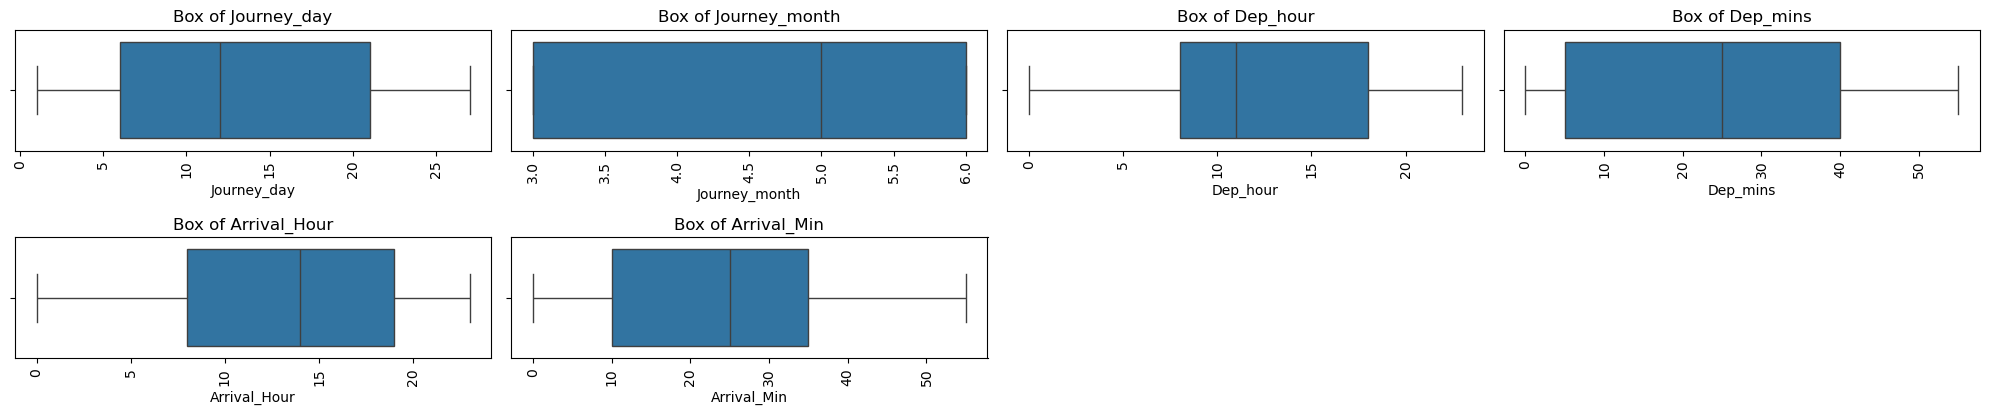

In [38]:
plt.figure(figsize=(20, 10))
plot = 1

for i in num_cols:   
        plt.subplot(5, 4, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

#### 10.1.4 Encoding

In [39]:
df[cat_cols].head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info


In [40]:
df[cat_cols].nunique()

Airline             12
Source               5
Destination          6
Route              128
Total_Stops          5
Additional_Info     10
dtype: int64

In [41]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other
df.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [42]:
ordinal_encode_cols = ['Total_Stops']
onehot_encode_cols = ['Airline','Source','Destination']

In [43]:
# Ordinal Encoding — Total_Stops (natural order)
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stops_map)

In [44]:
# Target Encoding — Airline (high cardinality, strong price relationship)
global_mean = df['Price'].mean()
airline_mean = df.groupby('Airline')['Price'].mean()
df['Airline_encoded'] = df['Airline'].map(airline_mean)
df['Airline_encoded'].fillna(global_mean, inplace=True)
df.drop('Airline', axis=1, inplace=True)

In [45]:
# One-Hot Encoding — Source, Destination (nominal, low cardinality)
df = pd.get_dummies(df, columns=['Source', 'Destination'], drop_first=True,dtype='int32')
print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (10460, 19)


,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins,Airline_encoded,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,170,5668.469897,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,445,9556.608028,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,9,25,4,25,1140,11599.021081,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,18,5,23,30,325,5668.469897,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,285,5668.469897,0,0,0,0,0,0,0,0,1


#### 10.2 Feature selection

In [46]:
corr_matrix = df.corr()
price_corr = corr_matrix['Price'].sort_values(ascending=False)
price_corr

Price                    1.000000
Airline_encoded          0.638632
Total_Stops              0.601978
Duration_Mins            0.501710
Destination_Cochin       0.261410
Source_Delhi             0.261410
Destination_New Delhi    0.200019
Arrival_Hour             0.030821
Source_Kolkata           0.015350
Dep_hour                 0.005373
Dep_mins                -0.024177
Arrival_Min             -0.086295
Journey_month           -0.113605
Journey_day             -0.158995
Source_Chennai          -0.178141
Destination_Kolkata     -0.178141
Source_Mumbai           -0.229225
Destination_Hyderabad   -0.229225
Destination_Delhi       -0.311451
Name: Price, dtype: float64

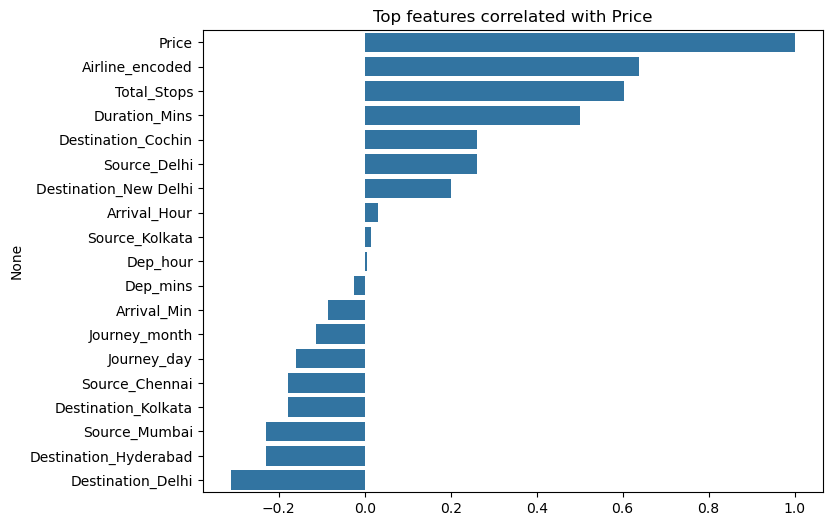

In [47]:
top_corr = price_corr[:]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features correlated with Price")
plt.show()

## 11. Modeling

### 11.1 Spliting the Data


In [48]:
# Spliting data in dependent and independent features
x = df.drop("Price",axis=1)
y = df.Price

In [49]:
x.head()

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins,Airline_encoded,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,170,5668.469897,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,445,9556.608028,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,1140,11599.021081,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,325,5668.469897,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,285,5668.469897,0,0,0,0,0,0,0,0,1


In [50]:
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

### 11.2 Train Test Split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [52]:
print('Train size:', x_train.shape)
print('Test size:', x_test.shape)

Train size: (7845, 18)
Test size: (2615, 18)


In [53]:
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

### 11.3 Model Building , Validating , Evaluation with and without Hyper Parameter Tuning

In [54]:
# Creating a funnction to run and evaluate the model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(x_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    return {
        "Model": name,
        "Train R2": r2_score(y_train, y_pred_train),
        "Test R2": r2_score(y_test, y_pred_test),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

#### 11.3.1 Linear Regression


In [55]:
lr = LinearRegression()
lr_results = evaluate_model(
    "Linear Regression",
    lr,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.2 Ridge Regression

In [56]:
ridge = Ridge(alpha=1.0)
ridge_results = evaluate_model(
    "Ridge Regression",
    ridge,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.3 Lasso Regression

In [57]:
lasso = Lasso(alpha=0.01)
lasso_results = evaluate_model(
    "Lasso Regression",
    lasso,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.4 Random Forest Regression

In [58]:
rf = RandomForestRegressor()
rf_results = evaluate_model(
    "Random Forest",
    rf,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.5 GradientBoosting Regression

In [59]:
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gbr_results = evaluate_model(
    "Gradient Boosting",
    gbr,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.6 XGBoosting Regression

In [60]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

### 11.4 Best Model Based On Train R2, Test R2, MAE, RMSE

In [61]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    rf_results,
    gbr_results,
    xgb_results
])

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,MAE,RMSE
4,Gradient Boosting,0.092477,0.087667,3499.184561,4295.225769
5,XGBoost,0.010815,0.007933,3774.191895,4478.987609
3,Random Forest,-0.086722,-0.106054,3893.533080,4729.306936
2,Lasso Regression,-1.391034,-1.540321,6159.670770,7167.266918
1,Ridge Regression,-1.402872,-1.552982,6181.892971,7185.105639
0,Linear Regression,-1.404183,-1.554577,6183.912144,7187.350421


## 12 Hyperparameter Tuning

###  12.1 Random Forest

In [62]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

In [63]:
# Create the random grid

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [64]:
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid,scoring='neg_mean_squared_error', n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [65]:
rf_random.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   4.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   4.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   4.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   4.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   4.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   7.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   7.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimator

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [66]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 25}

In [67]:
rf1 = RandomForestRegressor(n_estimators = 1000, min_samples_split= 2, min_samples_leaf= 1, max_features= 'sqrt', max_depth= 25)
rf1_results = evaluate_model(
    " Tuned Random Forest ",
    rf,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

In [68]:
rf1_results

{'Model': ' Tuned Random Forest ',
 'Train R2': -0.06809454720373043,
 'Test R2': -0.08997607850753497,
 'MAE': 3879.7308680688334,
 'RMSE': np.float64(4694.8076229899225)}

### 12.2 XGBoost

In [69]:
n_estimators = [int(x) for x in np.linspace(start=100, stop=1200, num=12)]
# Learning rate — controls how much each tree contributes
learning_rate = [0.01, 0.05, 0.1, 0.2, 0.3]
# Maximum depth of each tree
max_depth = [int(x) for x in np.linspace(3, 15, num=6)]
# Minimum sum of instance weight needed in a child
min_child_weight = [1, 3, 5, 7, 10]
# Fraction of samples used per tree
subsample = [0.6, 0.7, 0.8, 0.9, 1.0]
# Fraction of features used per tree
colsample_bytree = [0.6, 0.7, 0.8, 0.9, 1.0]
# L1 regularization
reg_alpha = [0, 0.01, 0.1, 0.5, 1]
# L2 regularization
reg_lambda = [0.5, 1, 1.5, 2, 5]

In [70]:
random_grid = {'n_estimators': n_estimators,
               'learning_rate':learning_rate,
               'max_depth': max_depth,
               'min_child_weight': min_child_weight,
               'subsample': subsample,
               'colsample_bytree': colsample_bytree,
               'reg_alpha':reg_alpha,
               'reg_lambda': reg_lambda}

In [71]:
xgb_random = RandomizedSearchCV(estimator = xgb, param_distributions = random_grid,scoring='neg_mean_squared_error', n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [72]:
xgb_random.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   1.7s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   1.6s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.8, learning_rate=0.3, max_depth=15, min_child_weight=5, n_estimators=600, reg_alpha=0.

KeyboardInterrupt: 

In [ ]:
xgb_random.best_params_

In [ ]:
xgb2 = XGBRegressor(subsample= 0.6,
 reg_lambda= 2,
 reg_alpha= 0,
 n_estimators=800,
 min_child_weight= 3,
 max_depth= 5,
 learning_rate= 0.1,
 colsample_bytree= 1.0)
xgb2_results = evaluate_model(
    "Tuned XGBoost",
    xgb2,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

In [ ]:
xgb2_results

In [ ]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    rf_results,
    rf1_results,
    gbr_results,
    xgb_results,
    xgb2_results
])

results_df.sort_values(by="Test R2", ascending=False)

In [ ]:
sorted_df = results_df.sort_values(by='Test R2', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=sorted_df,
    y='Model',
    x='Test R2',
    palette='mako'
)
ax.set_title('Model Comparison by Test data R² Score', fontsize=16, pad=15)
ax.set_xlabel('Test R² Score', fontsize=13)
ax.set_ylabel('Model', fontsize=13)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3) 
plt.tight_layout()
plt.show()

In [ ]:
best_row = results_df.loc[results_df['Test R2'].idxmax()]
best_model_name = best_row['Model']
best_model_metrics = best_row[['Train R2' , 'Test R2', 'MAE', 'RMSE']]
print("="*45)
print(f"\nBest Model: {best_model_name}")
print("="*45)
print(best_model_metrics.to_string())

In [ ]:
with open("model.pkl","wb") as f:
    pickle.dump(xgb2,f)

In [ ]:
# Load a preprocessor object from a pickled file
with open("Model.pkl","rb") as f:
    preprocessor=pickle.load(f)